In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [45]:
!unzip '/content/drive/MyDrive/Group i.zip'

Archive:  /content/drive/MyDrive/Group i.zip
   creating: Group i/
   creating: Group i/Faa_End/
  inflating: Group i/Faa_End/AHCR_00001_Faa_End_10.jpg  
  inflating: Group i/Faa_End/AHCR_00001_Faa_End_11.jpg  
  inflating: Group i/Faa_End/AHCR_00001_Faa_End_2.jpg  
  inflating: Group i/Faa_End/AHCR_00001_Faa_End_3.jpg  
  inflating: Group i/Faa_End/AHCR_00002_Faa_End_10.jpg  
  inflating: Group i/Faa_End/AHCR_00002_Faa_End_11.jpg  
  inflating: Group i/Faa_End/AHCR_00002_Faa_End_2.jpg  
  inflating: Group i/Faa_End/AHCR_00002_Faa_End_3.jpg  
  inflating: Group i/Faa_End/AHCR_00004_Faa_End_10.jpg  
  inflating: Group i/Faa_End/AHCR_00004_Faa_End_11.jpg  
  inflating: Group i/Faa_End/AHCR_00004_Faa_End_2.jpg  
  inflating: Group i/Faa_End/AHCR_00004_Faa_End_3.jpg  
  inflating: Group i/Faa_End/AHCR_00005_Faa_End_10.jpg  
  inflating: Group i/Faa_End/AHCR_00005_Faa_End_11.jpg  
  inflating: Group i/Faa_End/AHCR_00005_Faa_End_2.jpg  
  inflating: Group i/Faa_End/AHCR_00005_Faa_End_3.jpg  

In [46]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

img_width, img_height = 150, 150
data_dir = "/content/Group i"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))  

    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):  
            for img_file in os.listdir(group_path): 
                img_path = os.path.join(group_path, img_file)
                try:
                    img = tf.keras.preprocessing.image.load_img(
                        img_path, target_size=(img_width, img_height), color_mode='grayscale'
                    )
                    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {img_file} in {group_name}: {e}")

    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

if len(images) == 0:
    raise ValueError("No images were loaded. Check the data directory and file paths.")

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(f"Training samples: {x_train.shape[0]}, Testing samples: {x_test.shape[0]}")
print(f"Number of classes: {num_classes}")


Training samples: 2952, Testing samples: 739
Number of classes: 8


In [50]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [51]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


185/185 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.1337 - loss: 2.1111 - val_accuracy: 0.1664 - val_loss: 2.0030
Epoch 2/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.2686 - loss: 1.8912 - val_accuracy: 0.5142 - val_loss: 1.3819
Epoch 3/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.4145 - loss: 1.5301 - val_accuracy: 0.5940 - val_loss: 1.1650
Epoch 4/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.5211 - loss: 1.2874 - val_accuracy: 0.6752 - val_loss: 0.9800
Epoch 5/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.5406 - loss: 1.2237 - val_accuracy: 0.7253 - val_loss: 0.8344
Epoch 6/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.5943 - loss: 1.0964 - val_accuracy: 0.7321 - val_loss: 0.7945
Epoch 7/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6259 - loss: 1.0565 - val_accuracy: 0.7240 - val_loss: 0.8080
Epoch 8/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.6296 - loss: 1.0197 - val_accuracy: 0.

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8624 - loss: 0.4451
Train Accuracy: 78.32%
Test Accuracy: 84.44%


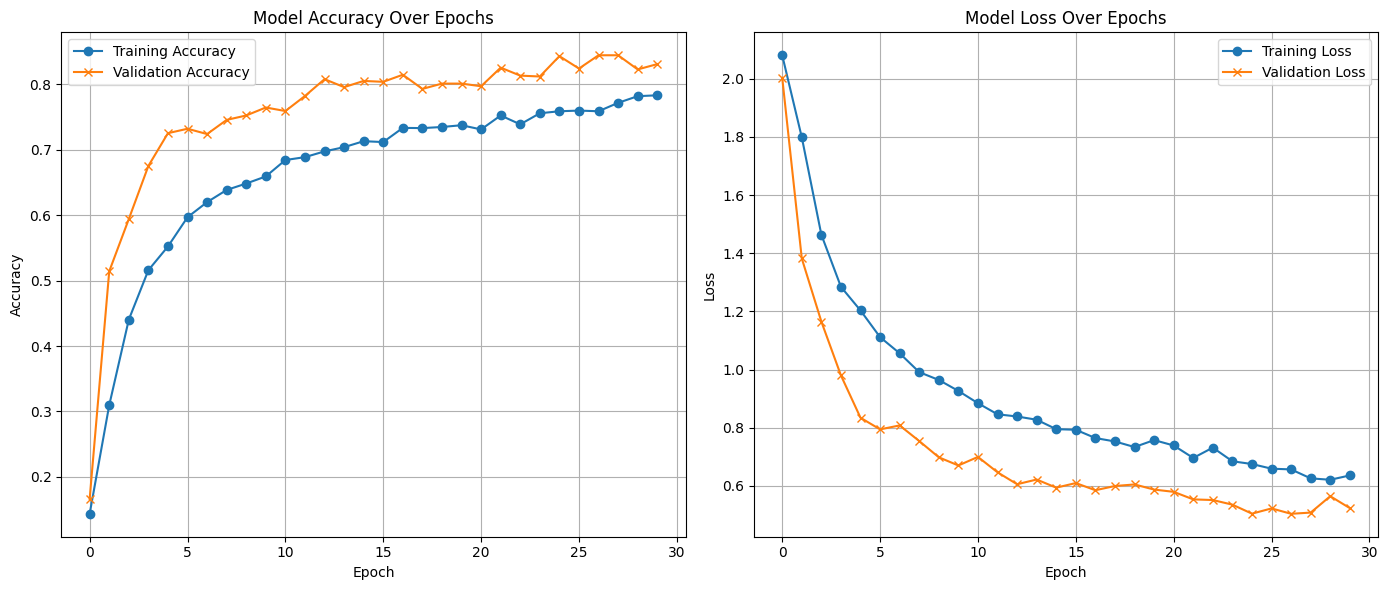

In [53]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


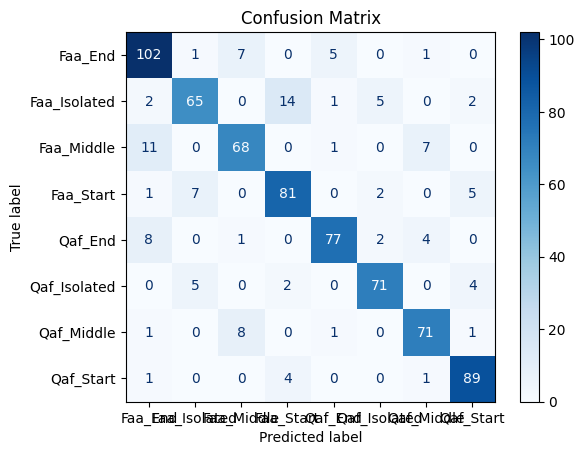

In [54]:

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


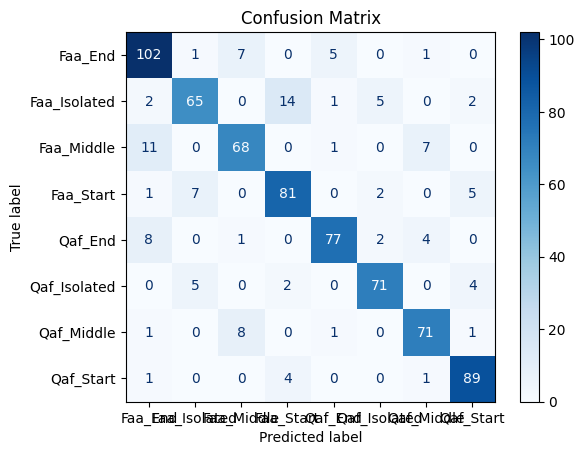

Number of incorrect predictions: 115


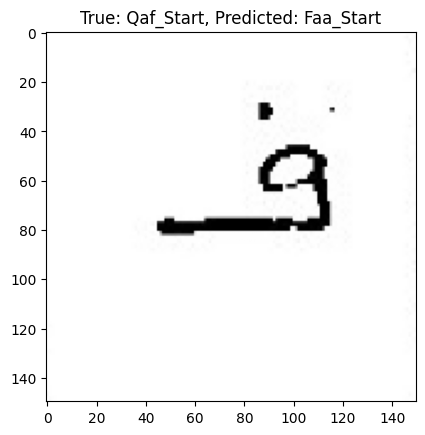

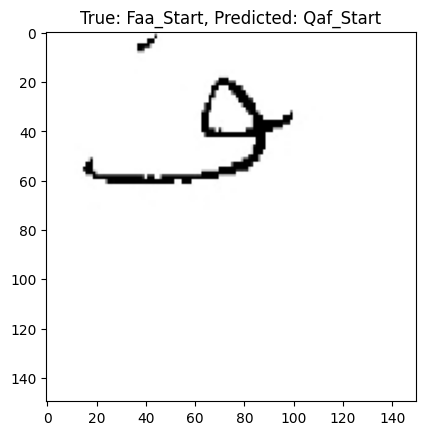

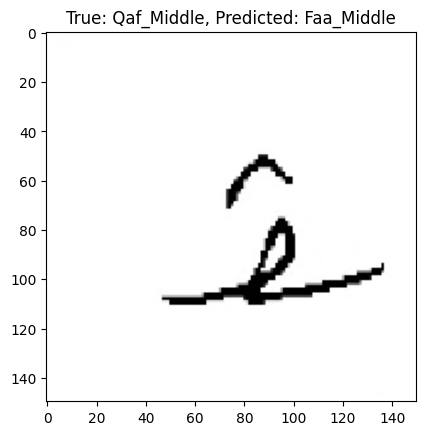

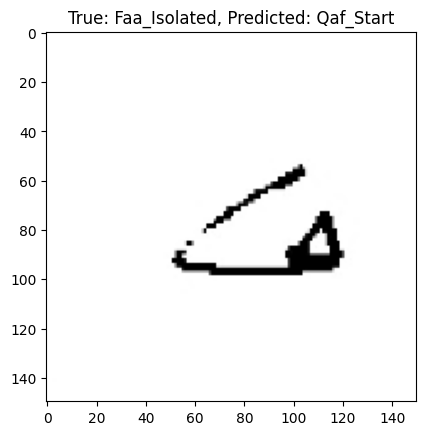

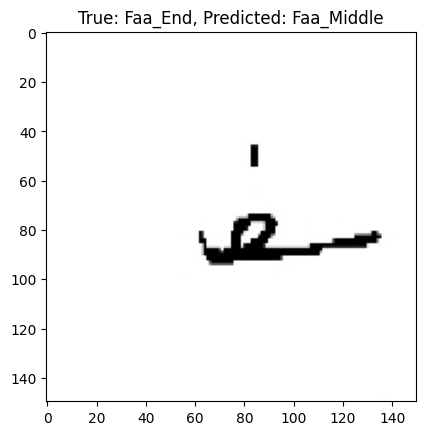

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### remove dropOut and decrease epochs 

In [57]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [58]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=28,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/28


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


185/185 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.1315 - loss: 2.2703 - val_accuracy: 0.3221 - val_loss: 1.7965
Epoch 2/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.3087 - loss: 1.7828 - val_accuracy: 0.4790 - val_loss: 1.3808
Epoch 3/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.4786 - loss: 1.3925 - val_accuracy: 0.6076 - val_loss: 1.0901
Epoch 4/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.5934 - loss: 1.1090 - val_accuracy: 0.6739 - val_loss: 0.9348
Epoch 5/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.6459 - loss: 0.9986 - val_accuracy: 0.6793 - val_loss: 0.8381
Epoch 6/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.6699 - loss: 0.9232 - val_accuracy: 0.7158 - val_loss: 0.8209
Epoch 7/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.6866 - loss: 0.8380 - val_accuracy: 0.7212 - val_loss: 0.7468
Epoch 8/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.7104 - loss: 0.7895 - val_accuracy: 0

In [61]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8427 - loss: 0.5027
Train Accuracy: 81.71%
Test Accuracy: 82.81%


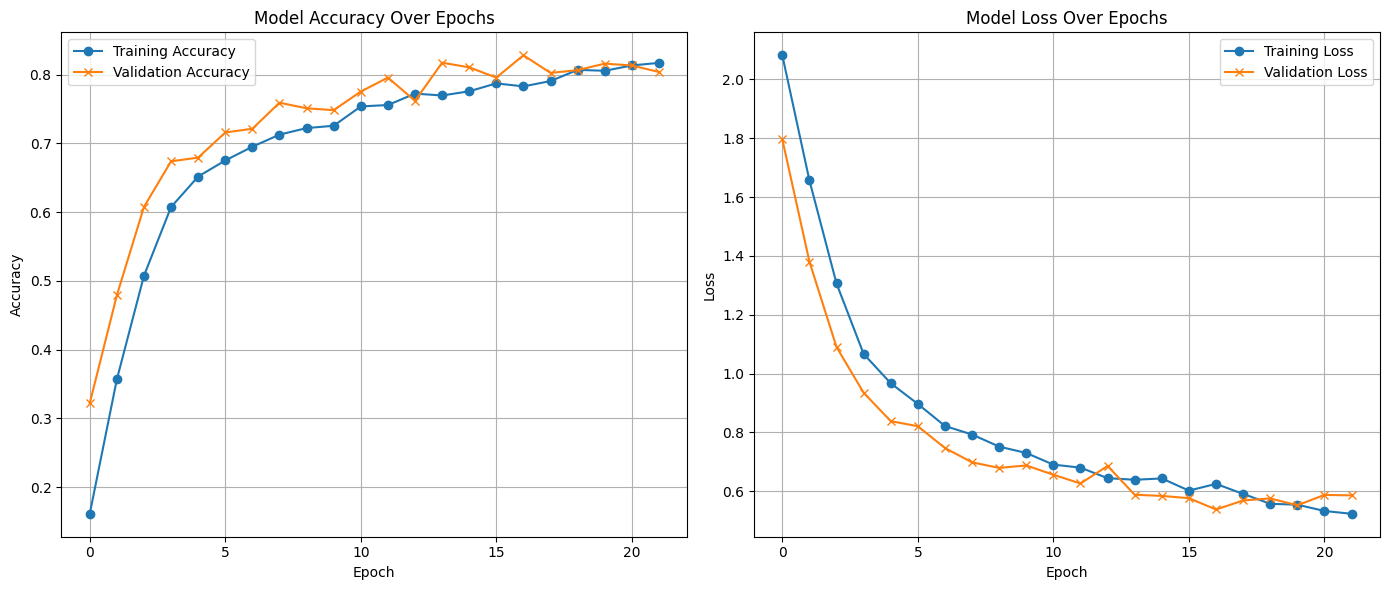

In [62]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


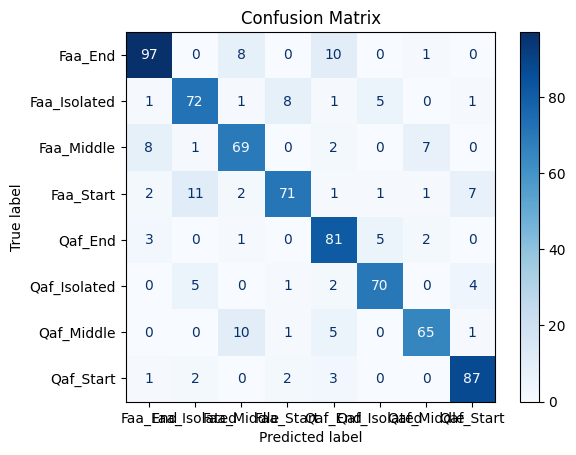

Number of incorrect predictions: 127


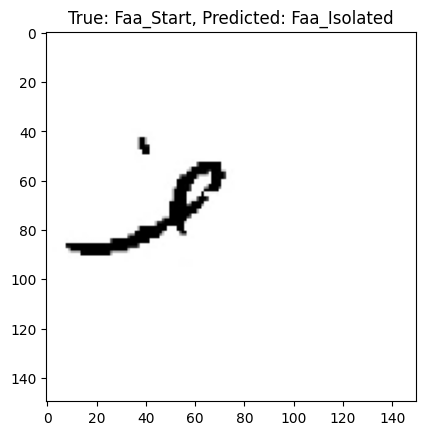

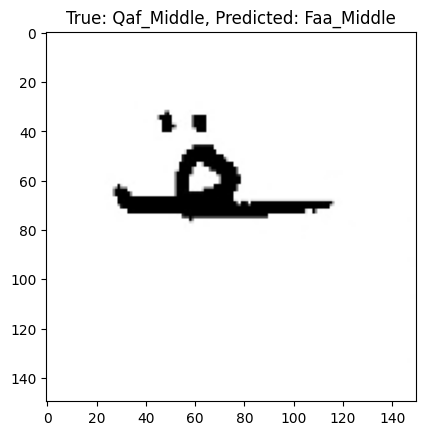

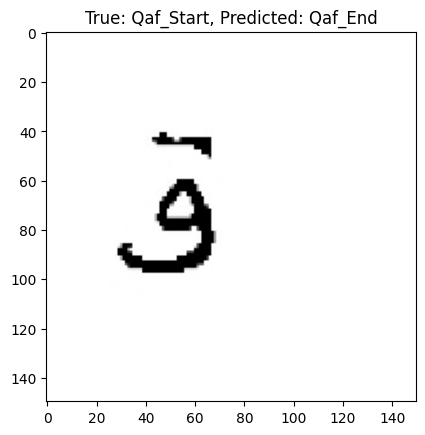

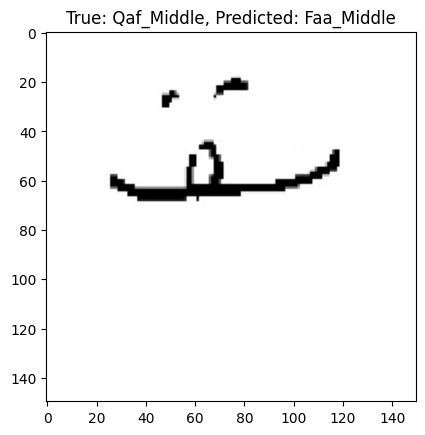

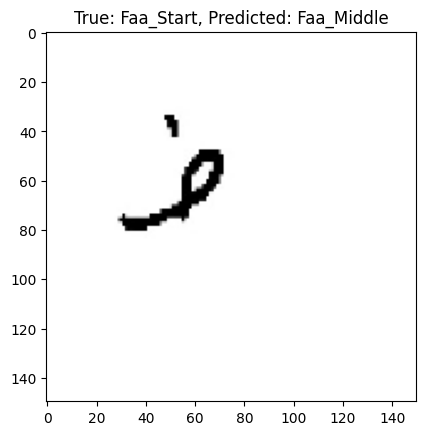

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### increase epochs (more training )

In [78]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.7055 - loss: 0.8330 - val_accuracy: 0.7686 - val_loss: 0.6878
Epoch 2/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.7405 - loss: 0.7324 - val_accuracy: 0.7781 - val_loss: 0.6662
Epoch 3/30
182/185 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7473 - loss: 0.7079Epoch 4/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.7710 - loss: 0.6275 - val_accuracy: 0.7700 - val_loss: 0.6620
Epoch 5/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.7777 - loss: 0.6087 - val_accuracy: 0.7943 - val_loss: 0.6137
Epoch 6/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.7815 - loss: 0.5991 - val_accuracy: 0.8011 - val_loss: 0.5589
Epoch 7/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.8035 - loss: 0.5578 - val_accuracy: 0.7997 - val_loss: 0.6041
Epoch 8/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8071 - loss: 0.5279 - val_accuracy: 0.8038 - val_loss: 0.5566
Epoch 9/

In [79]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8490 - loss: 0.4003 
Train Accuracy: 83.91%
Test Accuracy: 83.90%


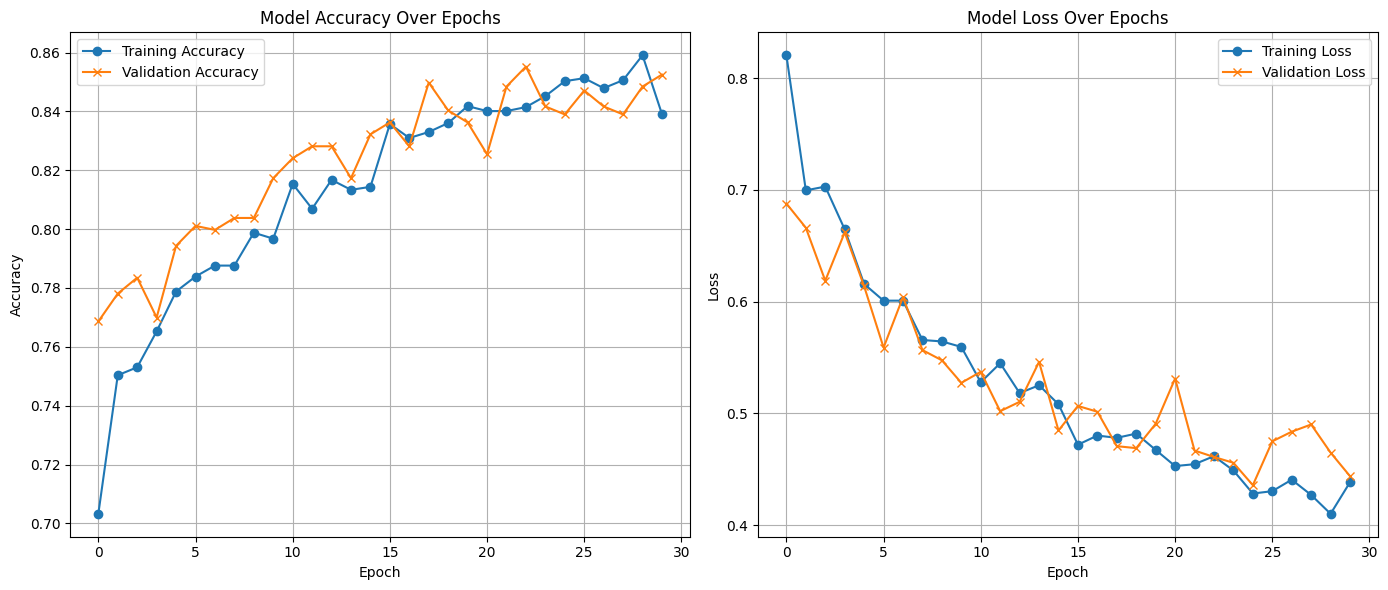

In [80]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


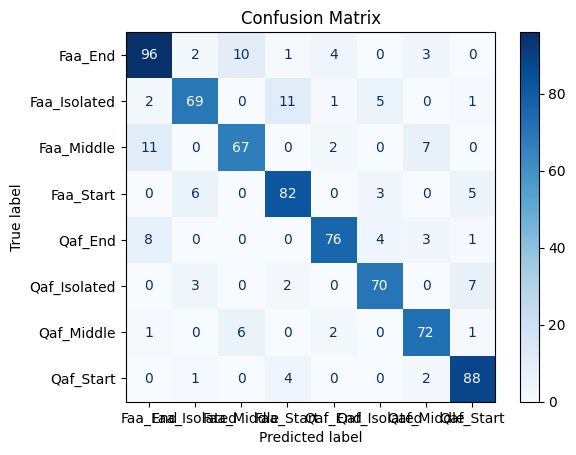

Number of incorrect predictions: 119


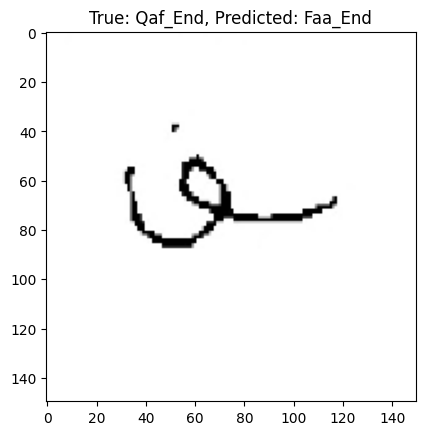

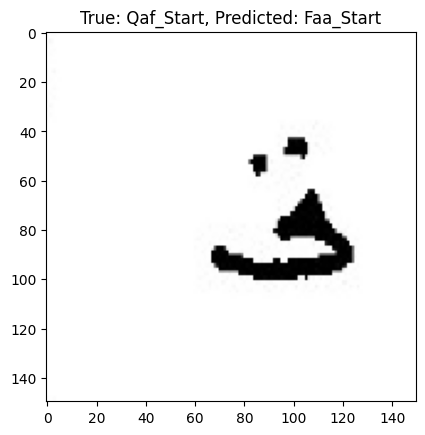

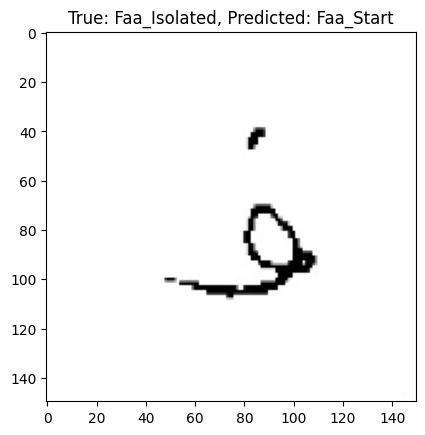

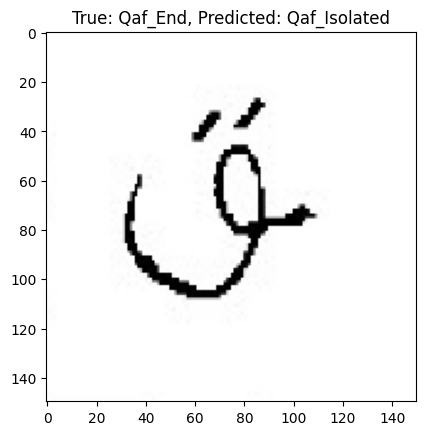

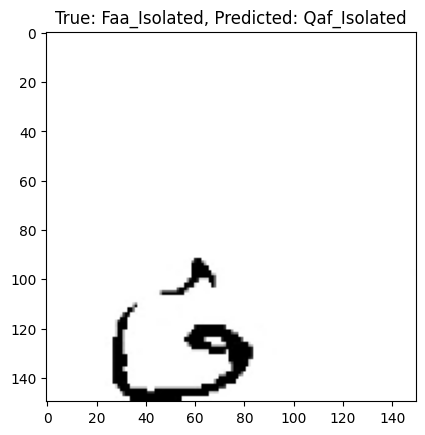

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


In [82]:
model.save("GrpI.keras")